# Titled Tuesday Command Center
Run top-to-bottom every Tuesday morning. Update the config cell first.

In [1]:
gct_finals = [
    # Grand Chess Tour Finals
    "Fabiano Caruana",
    "Vincent Keymer",
    "Wesley So",
    "Praggnanandhaa Rameshbabu",
    ]
slovakia = [
    "Alexander Donchenko",
    "Leon Luke Mendonca",
    "Abhimanyu Mishra",
    "David Navara",
    "Ihor Samunenkov",
    "Anton Korobov",
    "Daniel Dardha",
    "Mittal Aditya", 
    "Alexandr Fier",
    "Jergus Pechac"
]
barcelona = [
    "Jules Moussard",
    "Sergey A. Fedorchuk",
    "Valery Kazakouski",
    "S.P. Sethuraman",
    "Jakub Kosakowski",
    "Loic Travadon",
    "Jorge Roberto Elias Reyes",
    "Atilla Kuru",
    "Rishi Sardana",
    "Daniel Alsina Leal",
    "Carles Diaz Camallonga",
    "Sauat Nurgaliyev",
    "Yuri Solodovnichenko",
    "Nico Chasin",
    "Hipolito Asis Gargatagli",
    "Dylan Isidro Berdayes Ason",
    "Javier Habans Aguerrea",
    "Adiga Sathvik",
    "Sunle Gong",
    "Dey Shahil",
    "Tiger Hillarp Persson",
    "Teimur Toktomushev",
    "Santiago Lopez Rayo",
    "Manuel Campos Gomez",
    "Arad Nazari",
    "Siddharth Singh",
    "Steven Rojas Salas",
    "Kassa Korley",
    "Mauricio Emmanuel Marrujo Pardo",
    "Cristhian Camilo Rios Gomez",
    "Erdene Baasansuren",
    "Filip Cukrowski",
    "Kevin Noboa Silva",
    "Guerau Masague Artero",
    "Roberto Carlos Gomez Ledo",
    "Irina Krush",
    "Robert Stein",
    "Abel Lazaro Pujol",
    "Bartlomiej Niedbala",
    "Felix Xie",
    "Jachym Smolik",
    "Marc Narciso Dublan",
    "Leo Valle Luis",
    "Giuseppe Lettieri",
    "Yifan(Hlj) Hou",
    "Luis Daniel Rodriguez Hernandez",
    "Noam Sason",
    "Alberto Atoyan",
    "Cristian Vitier Vazquez",
    "Cristian Andres Hernandez",
    "Chatterjee Utsab",
    "Adrian Musat",
    "Miguel Ruiz Buendia",
    "Mandar Pradip Lad",
    "Hilmir Freyr Heimisson",
    "Julio Javier Alonso Bouza",
    "Fernando Valenzuela Gomez",
    "Marc Llari",
    "Carlos Alberto Chavez Suarez",
    "Jan Lajbl",
    "Eric Dominguez Pons",
    "Anastasios Georgiadis",
    "Gianmarco Leiva",
    "Cesar Alcala Gonzalez",
    "Caleb Levi Levitan"
]

In [2]:
# ── Weekly Config — update these each Tuesday ─────────────────────────────────
TOURN_DATE = "2026-08-25"   # Next Tuesday's date (YYYY-MM-DD)

# ── Attendance adjustments ─────────────────────────────────────────────────────
CUT_PLAYERS = gct_finals+slovakia+barcelona

KEEP_PLAYERS = []

P_OVERRIDES = {             # player → exact p_participate (e.g. 0.3 = 30%)
}

P_NUDGES    = {
}

SAVE_OFFICIAL = True       # set True to persist to DB (do after finalising adjustments)

In [ ]:
import sys
sys.path.insert(0, '..')

import re
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import requests

from src.config import DB_PATH
from src.data import get_username_mappings, load_model_predictions
from src.kalshi_api import KalshiClient
from src.trading import take_trades
from src.pipeline import run_raw, run_adjusted, load_adj_run_from_db, load_raw_results_from_db
from src.portfolio import (
    build_portfolio, run_portfolio_mc_score, pnl_summary,
)
from src.visualization import (
    plot_top_players_by_chance, plot_yes_no_prices,
    plot_ip_advantage, plot_pnl_histogram,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 120)

USERNAME_TO_PLAYER, PLAYER_TO_USERNAME = get_username_mappings()
print('Imports OK')

---
## 2 — Run predictions

In [ ]:
# ── Reload from DB (no simulation) ────────────────────────────────────────────
# Run this cell when re-opening the notebook to restore the last saved run.
# Rebuilds pool arrays from standings (~5s); skips the 60s MC simulation.
# Then run run_adjusted() below if attendance adjustments have changed.
adj_run     = load_adj_run_from_db(TOURN_DATE)
results_raw = load_raw_results_from_db(TOURN_DATE)
results     = adj_run.results
print(f'\nPool: {len(results):,} players (loaded from DB)')

In [ ]:
# Run once — raw baseline (no attendance adjustments).
# Re-run only if historical data has been updated.
raw_run     = run_raw(TOURN_DATE, save_to_db=True)
results_raw = raw_run.results_raw
print(f'\nPool: {len(raw_run.results_raw):,} players')

In [5]:
# Re-run this cell freely as attendance data changes.
adj_run = run_adjusted(
    TOURN_DATE,
    cut_players=CUT_PLAYERS,
    keep_players=KEEP_PLAYERS,
    p_participate_overrides=P_OVERRIDES,
    p_nudges=P_NUDGES,
    save_official=SAVE_OFFICIAL,
)
results = adj_run.results
print(f'\nPool: {len(results):,} players')

Predicting for tournament date: 2026-08-25
  p_participate: decay-weighted EWMA with isotonic floor (p < 0.05)
  346 events | 10,288 unique players | 2020-01-07 to 2026-08-18
  Player pool: 7,066
  Pool: 7,066 players | simulating 100,000 tournaments (raw)...
  Applying 42 hard override(s) (42 cut(s) to 0, 0 value(s))...
  Simulating 100,000 tournaments (adjusted)...
Saved 7,066 rows -> latest_model_predictions (36 attendance_altered)

Pool: 7,066 players


---
## 4 — Top predictions table

Yellow rows had a manual adjustment applied.

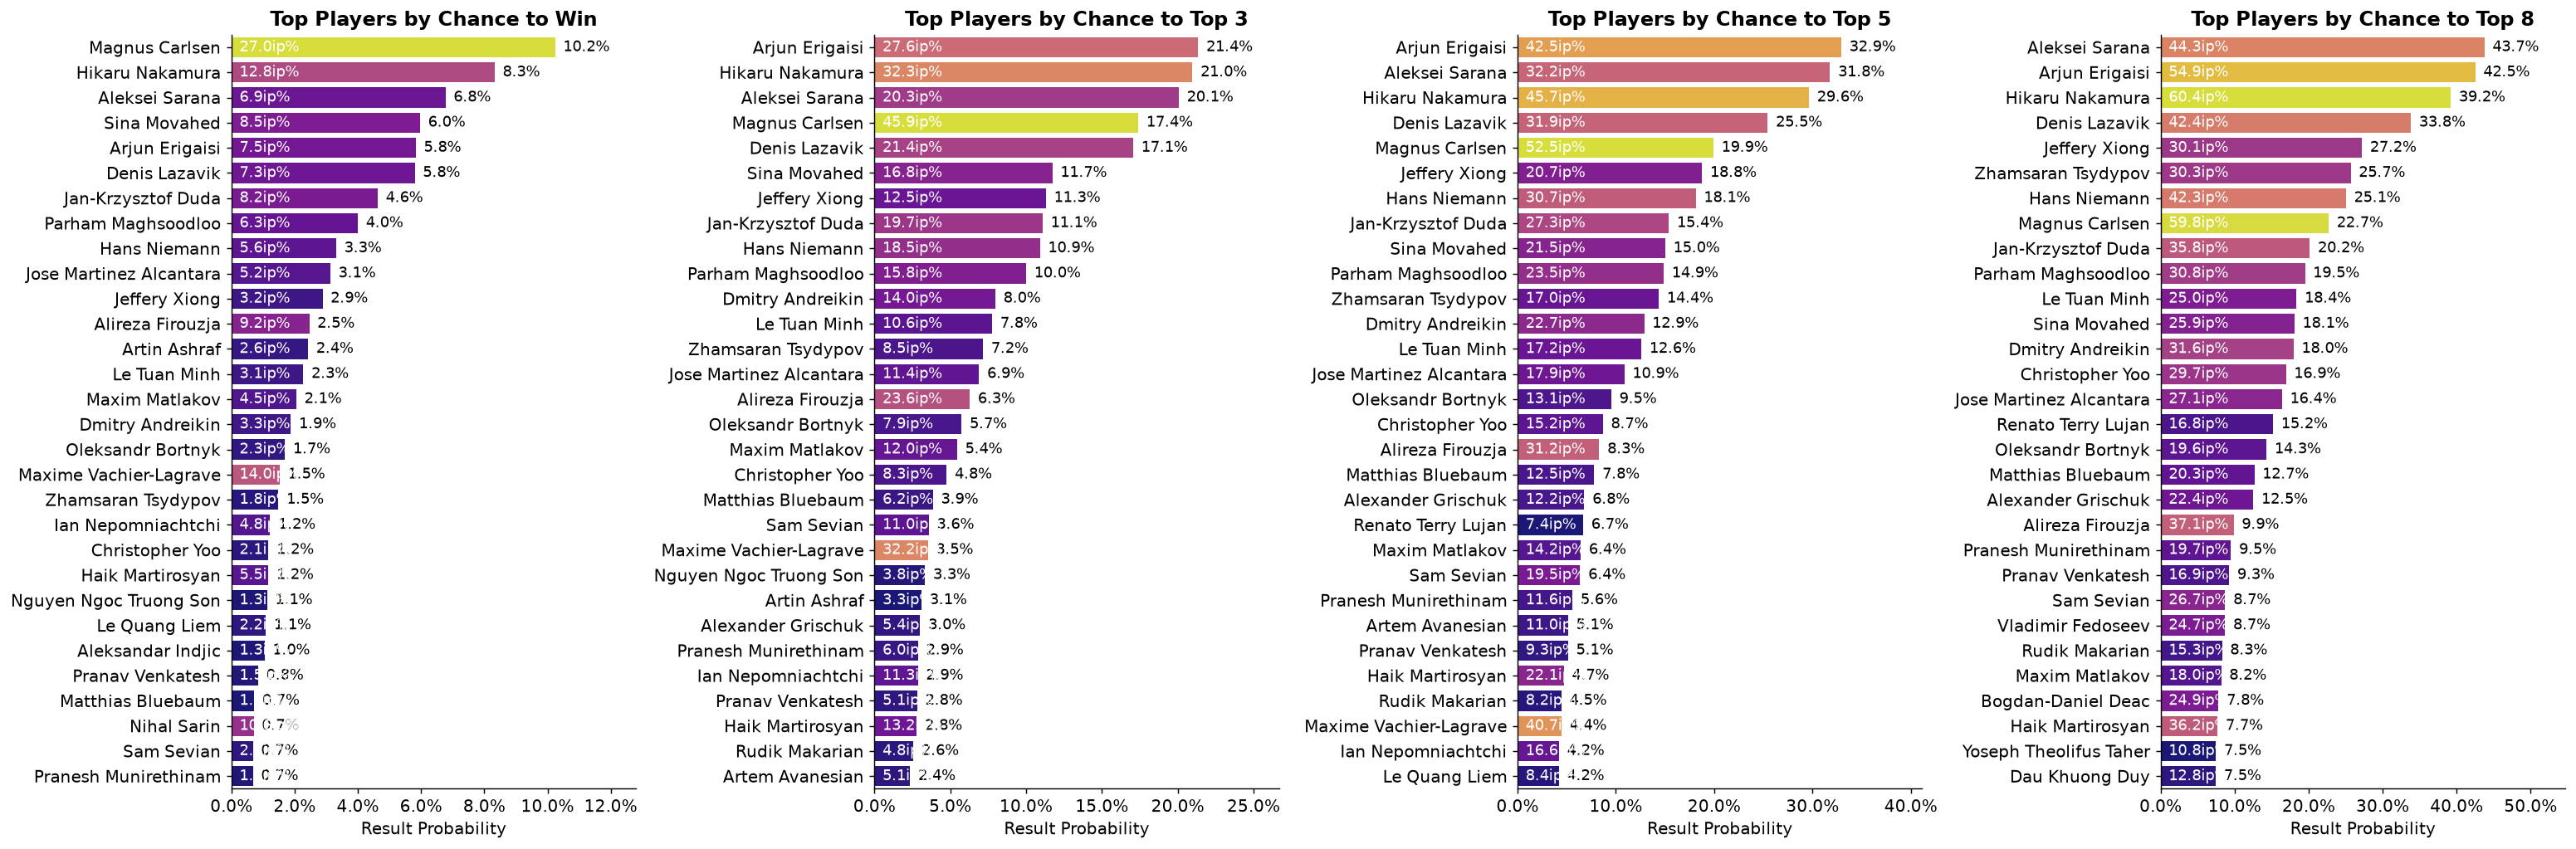

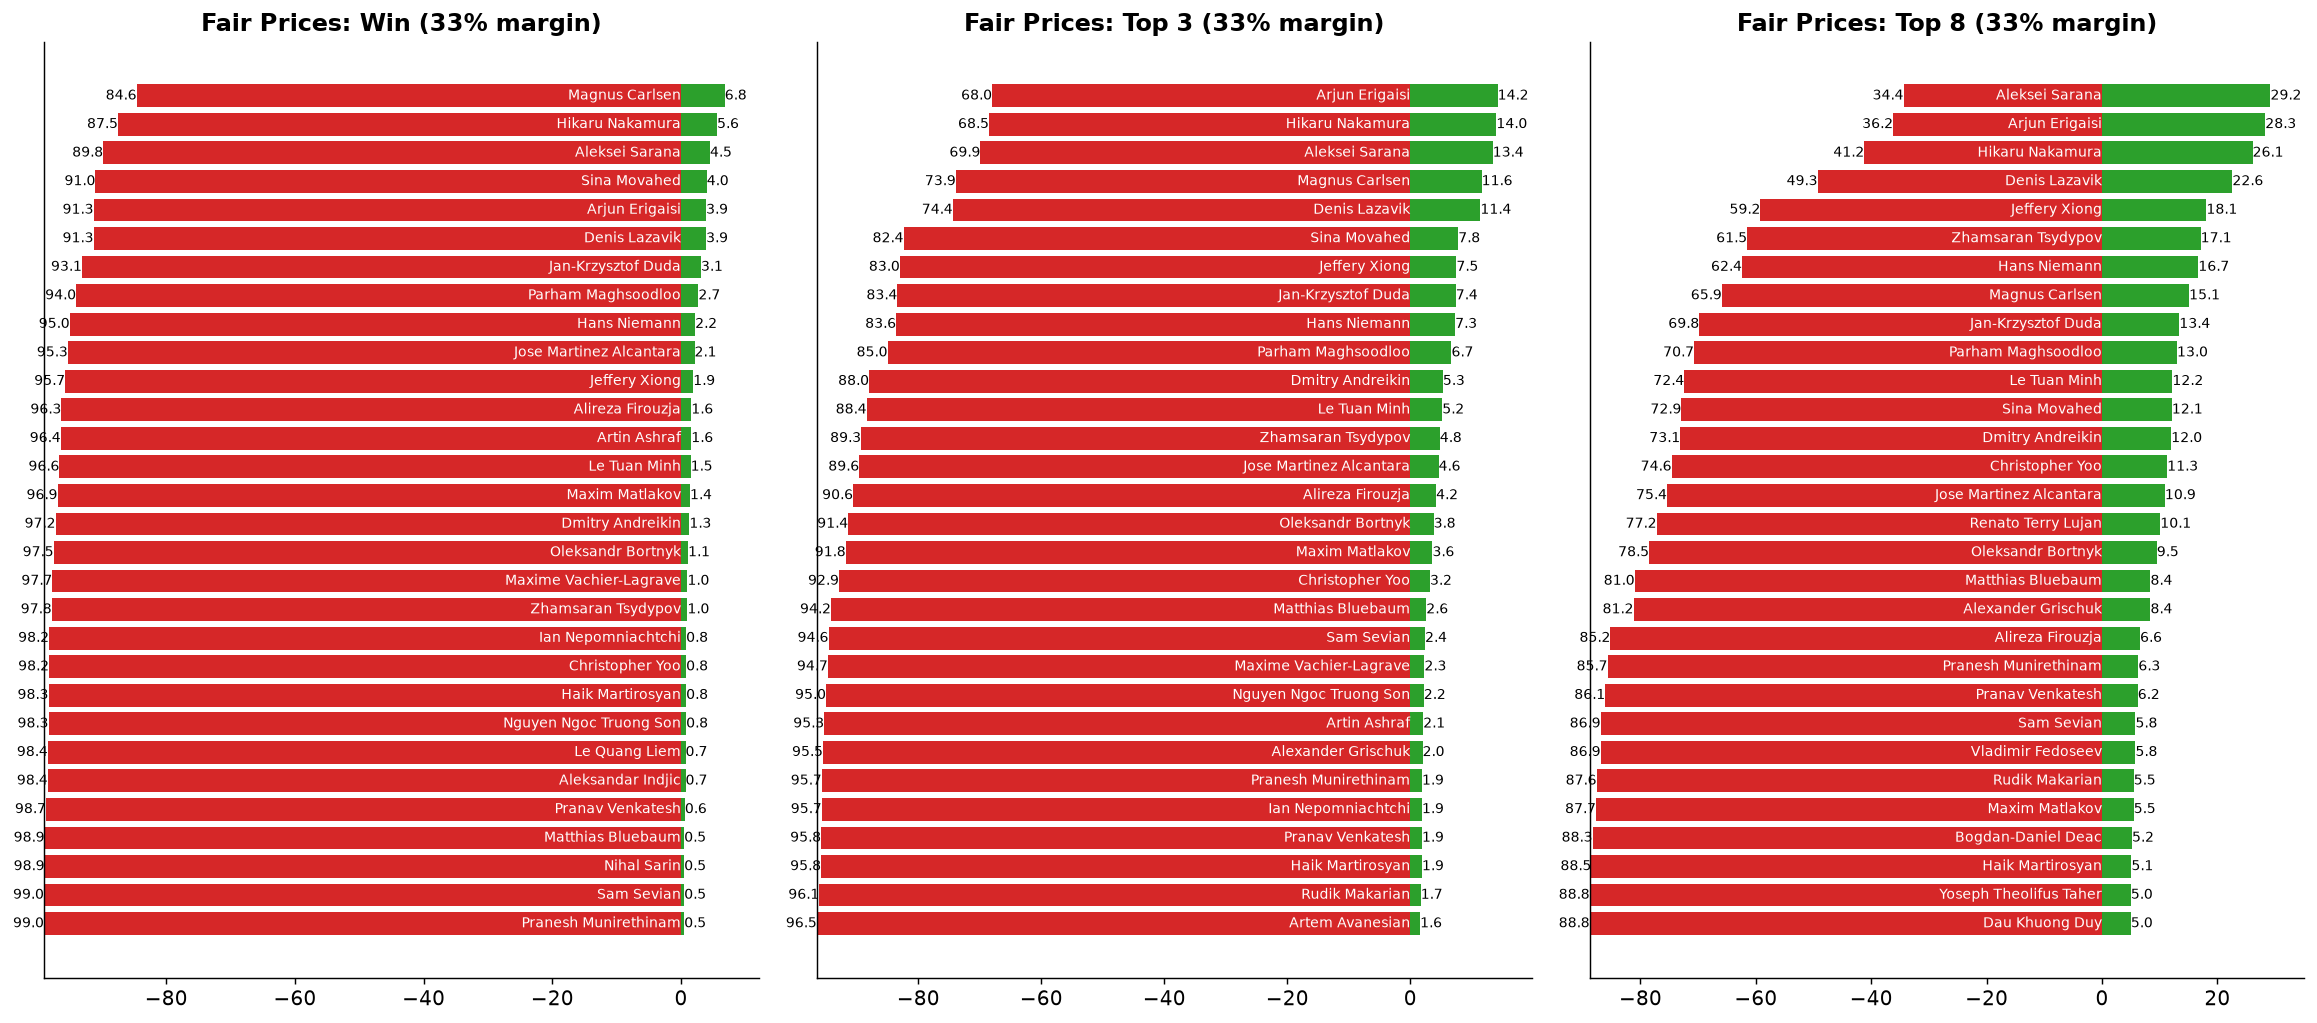

findfont: Failed to find font weight heavy, now using 700.


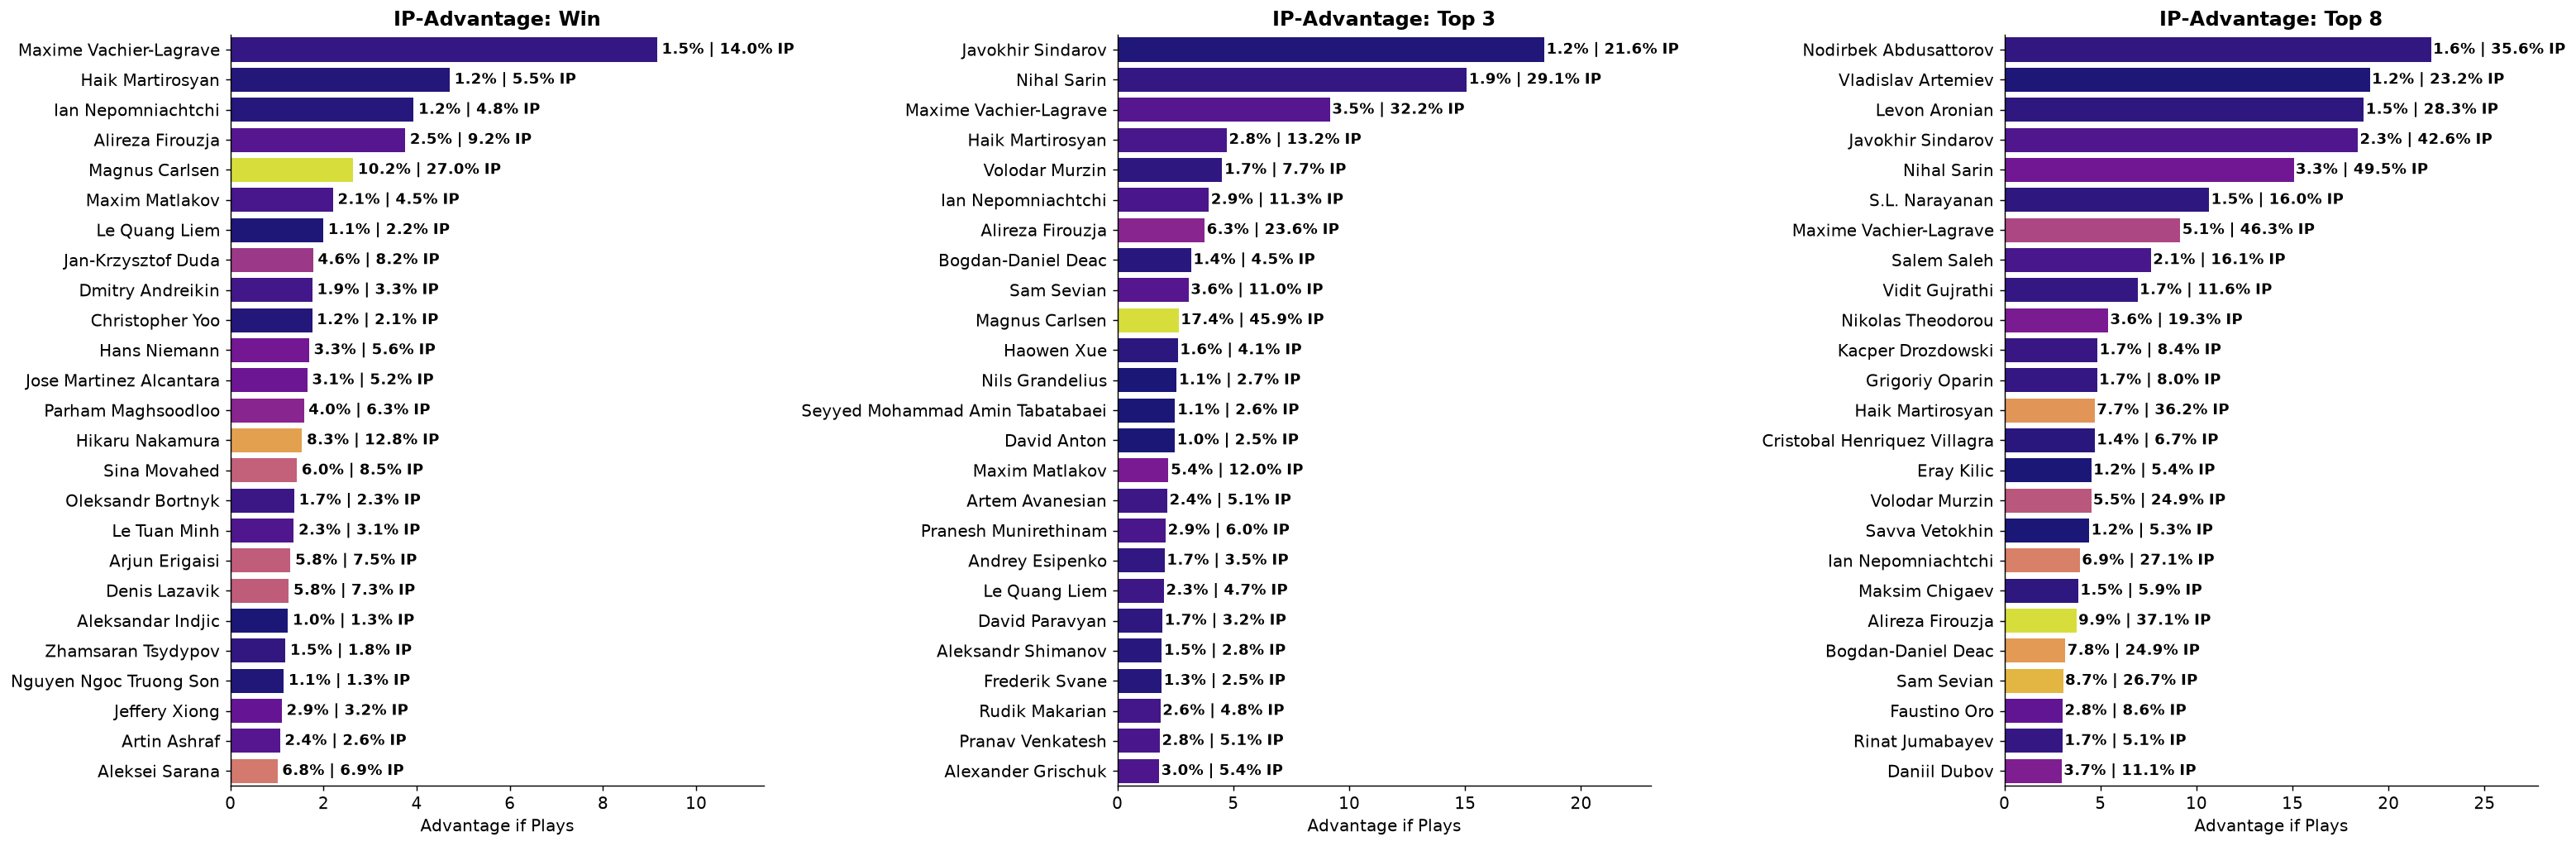

In [6]:
# ── Predictions visualizations ────────────────────────────────────────────────
plot_top_players_by_chance(results, USERNAME_TO_PLAYER)
plot_yes_no_prices(results, USERNAME_TO_PLAYER)
plot_ip_advantage(results, USERNAME_TO_PLAYER)

In [ ]:
# Plot Raw Results
plot_top_players_by_chance(results_raw, USERNAME_TO_PLAYER)
plot_yes_no_prices(results_raw, USERNAME_TO_PLAYER)
plot_ip_advantage(results_raw, USERNAME_TO_PLAYER)

---
## 5 — Portfolio P&L

Fetches current positions directly from Kalshi API for `TOURN_DATE`.

,ticker,marketTitle,n,position,volume,cost,avg_price
0,KXTITLEDTUESDAY-26AUG18-AERI,Arjun Erigaisi,1,Yes,2,$0.10,0.050
1,KXTITLEDTUESDAY-26AUG18-SMOV,Sina Movahed,1,Yes,4,$0.16,0.040
2,KXTITLEDTUESDAY-26AUG18-DAND,Dmitry Andreikin,1,Yes,2,$0.02,0.010
3,KXTITLEDTUESDAY-26AUG18-HNAM,Hikaru Nakamura,1,Yes,112,$4.47,0.040
4,KXTITLEDTUESDAY-26AUG18-DLAZ,Denis Lazavik,1,Yes,3,$0.12,0.040
5,KXTITLEDTUESDAY-26AUG18-JDUD,Jan-Krzysztof Duda,1,No,12,$9.90,0.840
6,KXTITLEDTUESDAY-26AUG18-OBOR,Oleksandr Bortnyk,1,Yes,2,$0.02,0.010
7,KXTITLEDTUESDAY-26AUG18-NSAR,Nihal Sarin,1,Yes,2,$0.02,0.010
8,KXTITLEDTUESDAY-26AUG18-LMIN,Le Tuan Minh,1,Yes,2,$0.02,0.010
9,KXTITLEDTUESDAY-26AUG18-HMAR,Haik Martirosyan,1,Yes,2,$0.02,0.010



Portfolio: 44 position(s), total cost $2146.13
Running P&L simulation (20k sims)...
   10,000 / 20,000  (4.1s)
   20,000 / 20,000  (8.1s)

── Portfolio (20,000 simulated tournaments) ──────────────
  Mean        : $+1686.84
  Std dev     : $2226.61
  5th pctile  : $-1911.34
  25th pctile : $+30.13
  Median      : $+1578.37
  75th pctile : $+3191.32
  95th pctile : $+5543.32
  Worst case  : $-2133.34
  Best case   : $+9873.40


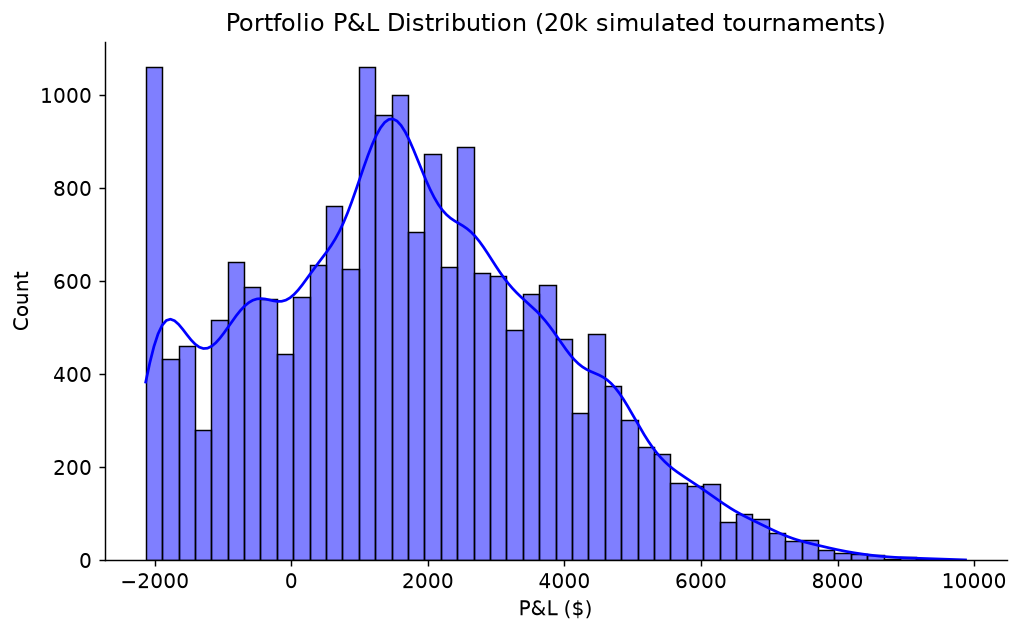

In [6]:
client = KalshiClient()
df_tt = client.get_tt_positions_df(TOURN_DATE)

if df_tt.empty:
    print(f'No TT positions found for {TOURN_DATE}.')
else:
    display(df_tt.style.format({'cost': '${:.2f}', 'avg_price': '{:.3f}', 'volume': '{:.0f}'}))
    print(f'\nPortfolio: {len(df_tt)} position(s), total cost ${df_tt["cost"].sum():.2f}')

    portfolio = build_portfolio(df_tt, adj_run.players, PLAYER_TO_USERNAME)
    print('Running P&L simulation (20k sims)...')
    pnl = run_portfolio_mc_score(
        adj_run.players, adj_run.p_play, adj_run.hist_composites, adj_run.hist_wts,
        portfolio, n_sims=20_000,
    )
    pnl_summary(pnl)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(x=pnl, kde=True, ax=ax, color='blue', bins=50)
    ax.set_title('Portfolio P&L Distribution (20k simulated tournaments)')
    ax.set_xlabel('P&L ($)')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

---
## 6 — Best trades (live Kalshi orderbook)

In [57]:
MIN_ROI=1.5
N_CONTRACTS=1
DRY_RUN=False

client = KalshiClient()
all_asks = client.get_titled_tuesday_asks(TOURN_DATE)
print(f'Fetched {len(all_asks)} orderbook levels for {TOURN_DATE}.')

KeyboardInterrupt: 

In [45]:
_results_raw = load_model_predictions().set_index('username')
for _n in [1, 3, 5, 8, 10]:
    _results_raw[f'P_top{_n}'] = _results_raw['p_participate'] * _results_raw[f'P_top{_n}_given_play']
    _results_raw[f'ip_adv_top{_n}'] = _results_raw[f'P_top{_n}_given_play'] / _results_raw[f'P_top{_n}']
results = _results_raw
def _kalshi_order_price(ask):
    return ask + 0.07 * ask * (1.0 - ask)

def _parse_n(title):
    """Extract top-N from market title. 'Winner' markets have no small number — return 1."""
    m = re.search(r'\b(Top\s+)?(\d+)\b', title or '')
    if not m:
        return 1
    val = int(m.group(2))
    # If the only number in the title is large (e.g. date like 28), it's the Winner market
    return val if val <= 10 else 1

df_ob = pd.DataFrame(all_asks)
df_ob['n'] = df_ob['Market Title'].apply(_parse_n)

# Resolve player names → usernames
df_ob['username'] = df_ob['Player Name'].map(lambda n: PLAYER_TO_USERNAME.get(n))
df_ob = df_ob[df_ob['username'].notna()].copy()

evs = []
for _, row in df_ob.iterrows():
    n = int(row['n'])
    col = f'P_top{n}'
    if row['username'] not in results.index or col not in results.columns:
        evs.append(None)
        continue
    p_yes = results.loc[row['username'], col]
    evs.append(float(p_yes) if row['Side'] == 'YES' else float(1.0 - p_yes))

df_ob['EV'] = evs
df_ob = df_ob[df_ob['EV'].notna()].copy()
df_ob['Order Price'] = df_ob['Ask Price ($)'].apply(_kalshi_order_price)
df_ob['Total Cost']  = df_ob['Quantity Available'] * df_ob['Order Price']
df_ob['Expected Return'] = (df_ob['EV'] - df_ob['Order Price']) * df_ob['Quantity Available'].astype(int)
df_ob['ROI'] = (df_ob['EV'] / df_ob['Order Price']).round(3)

df_edge = df_ob[df_ob['ROI'] > 1.2].copy()

exposure = df_edge["Total Cost"].sum()
exp_return = df_edge["Expected Return"].sum()
exp_roi = (exposure + exp_return)/exposure
print(f'Exposure (all edge positions): ${exposure:.2f}, expected return: ${exp_return:.2f}. ROI: {exp_roi:.2f}')
display(
    df_edge[['Market Title', 'n', 'Side', 'ROI', 'Order Price', 'EV', 'Quantity Available', 'Total Cost', 'Expected Return']]
    .sort_values(['n','ROI'], ascending=False)
    .style.format({
        'ROI': '{:.3f}', 'Order Price': '{:.3f}', 'EV': '{:.3f}',
        'Total Cost': '${:.2f}', 'Expected Return': '${:.2f}',
    })
)

KeyError: 'Market Title'

In [ ]:
#Automatically take trades with ROI > min_roi for the given date and max trades count.
result = take_trades(
        client,
        tourn_date=TOURN_DATE,
        min_roi=MIN_ROI,
        min_qty=20,
        dry_run=False,
    )

TypeError: take_trades() got an unexpected keyword argument 'count'

In [ ]:
display(
    df_edge[['Market Title', 'Side', 'ROI', 'Order Price', 'EV', 'Quantity Available', 'Total Cost', 'Expected Return']][df_edge['Side']=='NO']
    .sort_values('ROI', ascending=False)
    .style.format({
        'ROI': '{:.3f}', 'Order Price': '{:.3f}', 'EV': '{:.3f}',
        'Total Cost': '${:.2f}', 'Expected Return': '${:.2f}',
    })
)

,Market Title,Side,ROI,Order Price,EV,Quantity Available,Total Cost,Expected Return


In [ ]:
# ── Kelly sizing ──────────────────────────────────────────────────────────────
df_pos = df_edge.copy()
df_pos['kelly_f'] = (df_pos['EV'] - df_pos['Order Price']) / (1.0 - df_pos['Order Price'])

total_f = df_pos['kelly_f'].sum()
if total_f > 1.0:
    print(f'Sum of single-bet Kelly fractions = {total_f:.2f} — normalising to 1.0')
    df_pos['kelly_f'] /= total_f

df_pos['alloc_frac']   = df_pos['kelly_f'] * KELLY_MULT
df_pos['kelly_shares'] = (df_pos['alloc_frac'] * BANKROLL / df_pos['Order Price']).round().clip(lower=0).astype(int)
df_pos['kelly_cost']   = df_pos['kelly_shares'] * df_pos['Order Price']
df_pos['kelly_ev']     = df_pos['kelly_shares'] * df_pos['EV']
df_pos['kelly_edge']   = df_pos['kelly_ev'] - df_pos['kelly_cost']

df_kelly = df_pos[df_pos['kelly_shares'] > 0].copy()
total_cost = df_kelly['kelly_cost'].sum()
total_ev   = df_kelly['kelly_ev'].sum()
print(
    f'Bankroll ${BANKROLL:,.0f}  |  '
    f'Exposure ${total_cost:.0f} ({total_cost/BANKROLL*100:.1f}%)  |  '
    f'Expected edge ${total_ev - total_cost:.2f}  |  '
    f'Portfolio ROI {(total_ev/total_cost - 1)*100:.1f}%\n'
)
display(
    df_kelly[['Market Title', 'Side', 'ROI', 'Order Price', 'EV',
              'kelly_f', 'alloc_frac', 'kelly_shares', 'kelly_cost', 'kelly_edge']]
    .sort_values('kelly_f', ascending=False)
    .style.format({
        'Order Price': '{:.3f}', 'EV': '{:.3f}',
        'kelly_f': '{:.4f}', 'alloc_frac': '{:.4f}',
        'kelly_cost': '${:.2f}', 'kelly_edge': '${:.2f}',
    })
)

Sum of single-bet Kelly fractions = 3.54 — normalising to 1.0


NameError: name 'KELLY_MULT' is not defined